
# Orders - Datenbereinigung

## Setup

In [22]:
import pandas as pd

url = "https://drive.google.com/file/d/1lpq1D56gNcdJSl74qhYrYMvS_kXok6At/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id=" + url.split("/")[-2]
df_orders = pd.read_csv(path)

## Exploration

### Struktur verstehen

In [23]:
df_orders.shape
# (226909, 4) -> 226.909 Bestellungen, 4 Spalten

(226909, 4)

In [24]:
df_orders.info()
# created_date ist object (Text). Das ist ein falscher Datentyp

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226909 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      226909 non-null  int64  
 1   created_date  226909 non-null  object 
 2   total_paid    226904 non-null  float64
 3   state         226909 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.9+ MB


In [25]:
df_orders.head()
# erste 5 Zeilen: unterschiedliche states sichtbar

,order_id,created_date,total_paid,state
0,241319,2017-01-02 13:35:40,44.99,Cancelled
1,241423,2017-11-06 13:10:02,136.15,Completed
2,242832,2017-12-31 17:40:03,15.76,Completed
3,243330,2017-02-16 10:59:38,84.98,Completed
4,243784,2017-11-24 13:35:19,157.86,Cancelled


### Vollständigkeit prüfen

In [26]:
df_orders.isna().sum()
# total_paid hat 5 fehlende Werte

,0
order_id,0
created_date,0
total_paid,5
state,0


### Look for Duplicates



In [27]:
df_orders.duplicated().sum()
# 0 -> keine kompletten doppelten Zeilen

np.int64(0)

#### Duplicates für order_id

In [28]:
df_orders.duplicated(subset=['order_id']).sum()
# 0 -> auch keine doppelten order_id, jede Bestellung ist eindeutig

np.int64(0)

### Describe

In [29]:
df_orders.describe()
# Unterscheid zwischen median (50%) zu den oberen 25% (75%) bei total_paid ist zu hoch -> deutet auf Ausreißer hin

,order_id,total_paid
count,226909.000000,226904.000000
mean,413296.482480,569.225818
std,65919.250331,1761.778002
min,241319.000000,0.000000
25%,356263.000000,34.190000
50%,413040.000000,112.990000
75%,470553.000000,525.980000
max,527401.000000,214747.530000


### Auffällige Spalte visualisieren

<Axes: >

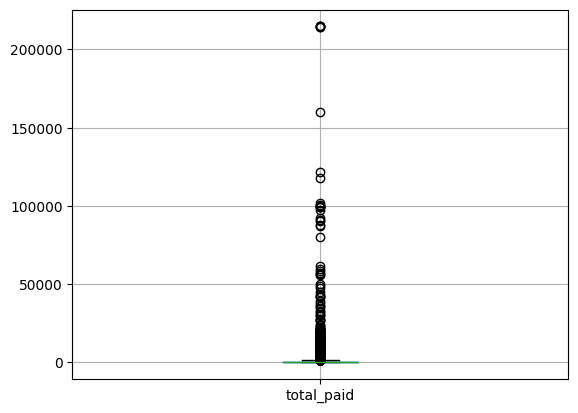

In [30]:
df_orders.boxplot(column='total_paid')
# zeigt mehrere Punkte weit oberhalb der Box -> bestätigt: es gibt Ausreißer

### Kategorische Spalten

In [31]:
df_orders['state'].value_counts()
# Shopping Basket    117809
# Completed           46605    <- das ist der tatsächliche, bezahlte Umsatz
# Place Order         40883
# Pending             14379
# Cancelled            7233

,count
state,
Shopping Basket,117809
Completed,46605
Place Order,40883
Pending,14379
Cancelled,7233


## Probleme dokumentieren

In [32]:
# - created_date ist als Text (object) gespeichert, sollte datetime sein
# - 5 fehlende Werte bei total_paid
# - Extreme Ausreißer bei total_paid (bis 214.747€), erkannt über describe() + Boxplot
# - state hat 5 Kategorien, nur "Completed" = tatsächlich abgeschlossener/bezahlter Umsatz

## Bereinigung

### created_date umwandeln

In [33]:
df_orders['created_date'] = pd.to_datetime(df_orders['created_date'])
df_orders.dtypes
# created_date ist jetzt datetime64 -> Umwandlung erfolgreich

,0
order_id,int64
created_date,datetime64[ns]
total_paid,float64
state,object


### fehlende total_paid-Werte untersuchen

In [34]:
df_orders[df_orders['total_paid'].isna()]
# 5 Zeilen betroffen, alle mit state == "Pending"

,order_id,created_date,total_paid,state
127701,427314,2017-11-20 18:54:39,NaN,Pending
132013,431655,2017-11-22 12:15:24,NaN,Pending
147316,447411,2017-11-27 10:32:37,NaN,Pending
148833,448966,2017-11-27 18:54:15,NaN,Pending
149434,449596,2017-11-27 21:52:08,NaN,Pending


### prozentualen Anteil innerhalb der Kategorie prüfen

In [35]:
df_orders[df_orders['state']=='Pending']['total_paid'].isna().sum() / len(df_orders[df_orders['state']=='Pending']) * 100
# das ist also KEIN normales Pending-Verhalten, sondern eine Ausnahme,
# vermutlich ein echter Datenfehler bei genau diesen 5 Bestellungen

np.float64(0.03477293274914806)

### fehlende Werte entfernen

In [36]:
df_orders = df_orders.dropna(subset=['total_paid'])
df_orders.shape
# Entscheidung: löschen, da es sich um eine Ausnahme (nicht Kategorie-Muster)
# handelt und der Anteil verschwindend gering ist (5 von 226.909 Zeilen)

(226904, 4)

### Ausreißer bei total_paid untersuchen

In [37]:
df_orders.sort_values('total_paid', ascending=False).head(10)
# Ergebnis: alle Top-10-Werte haben state == "Shopping Basket"
# keine echten abgeschlossenen Käufe, sondern liegengebliebene Warenkörbe
# Entscheidung: nicht löschen, da für spätere Umsatzfragen ohnehin nur
# state == "Completed" relevant sein wird

,order_id,created_date,total_paid,state
96028,395611,2017-09-01 20:56:34,214747.53,Shopping Basket
2478,301934,2017-01-03 19:27:13,214746.63,Shopping Basket
183927,484334,2018-01-07 15:58:26,214714.31,Shopping Basket
61659,361200,2017-06-01 11:55:02,214642.47,Shopping Basket
40557,340045,2017-03-28 13:27:52,214517.58,Shopping Basket
32296,331780,2017-03-03 22:29:21,159989.83,Shopping Basket
188457,488935,2018-01-11 21:11:34,121521.85,Shopping Basket
59492,359031,2017-05-25 12:14:22,117633.68,Shopping Basket
67674,367220,2017-06-19 17:42:14,101887.33,Shopping Basket
59208,358747,2017-05-24 14:51:58,100738.45,Shopping Basket


## Annahmen-Log

In [38]:
# - created_date wurde in datetime umgewandelt für spätere Zeitraum-Analysen
# - 5 fehlende total_paid-Werte wurden ENTFERNT
# - Extreme Ausreißer bei total_paid (bis 214.747€) betreffen ausschließlich
#   state="Shopping Basket" -> wahrscheinlich keine echten Käufe, werden für
#   Umsatzanalysen ohnehin über den state-Filter ausgeschlossen
# - Nur 21% aller Zeilen haben state="Completed" -> das ist der für Umsatzfragen
#   relevante Teil der Daten

## Export

In [39]:
# Zelle 1: Drive verbinden (einmal pro Sitzung)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [40]:
df_orders.to_csv('/content/drive/MyDrive/Projektarbeit2/CSV/Clean/orders_clean.csv', index=False)

# Orderlines - Datenbereinigung

## Setup

In [1]:
import pandas as pd

url = "https://drive.google.com/file/d/1FA-ERsMRVNQh4dXY8fyWZa56glUeHcmK/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id=" + url.split("/")[-2]
df_orderlines = pd.read_csv(path)

## Exploration

### Struktur verstehen

In [2]:
df_orderlines.shape
# (293983, 7) -> 293.983 bestellte Produkte, 7 Spalten

(293983, 7)

In [3]:
df_orderlines.info()
# date und unit_price sind objects (Text). Das sind falsche Datentypen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293983 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                293983 non-null  int64 
 1   id_order          293983 non-null  int64 
 2   product_id        293983 non-null  int64 
 3   product_quantity  293983 non-null  int64 
 4   sku               293983 non-null  object
 5   unit_price        293983 non-null  object
 6   date              293983 non-null  object
dtypes: int64(4), object(3)
memory usage: 15.7+ MB


In [4]:
df_orderlines.head()
# product_id ist immer 0

,id,id_order,product_id,product_quantity,sku,unit_price,date
0,1119109,299539,0,1,OTT0133,18.99,2017-01-01 00:07:19
1,1119110,299540,0,1,LGE0043,399.00,2017-01-01 00:19:45
2,1119111,299541,0,1,PAR0071,474.05,2017-01-01 00:20:57
3,1119112,299542,0,1,WDT0315,68.39,2017-01-01 00:51:40
4,1119113,299543,0,1,JBL0104,23.74,2017-01-01 01:06:38


### Vollständigkeit prüfen

In [5]:
df_orderlines.isna().sum()
# keine fehlenden Werte

,0
id,0
id_order,0
product_id,0
product_quantity,0
sku,0
unit_price,0
date,0


### Look for Duplicates

In [6]:
df_orderlines.duplicated().sum()
# 0 -> keine kompletten doppelten Zeilen

np.int64(0)

#### Duplicates für id

In [7]:
df_orderlines.duplicated(subset=['id']).sum()
# 0 -> auch keine doppelte id, jede Bestellung ist eindeutig

np.int64(0)

### Describe

In [8]:
df_orderlines.describe()
# Ausreißer bei product_quantity (max) gefunden

,id,id_order,product_id,product_quantity
count,2.939830e+05,293983.000000,293983.0,293983.000000
mean,1.397918e+06,419999.116544,0.0,1.121126
std,1.530096e+05,66344.486479,0.0,3.396569
min,1.119109e+06,241319.000000,0.0,1.000000
25%,1.262542e+06,362258.500000,0.0,1.000000
50%,1.406940e+06,425956.000000,0.0,1.000000
75%,1.531322e+06,478657.000000,0.0,1.000000
max,1.650203e+06,527401.000000,0.0,999.000000


### Auffällige Spalte visualisieren

<Axes: >

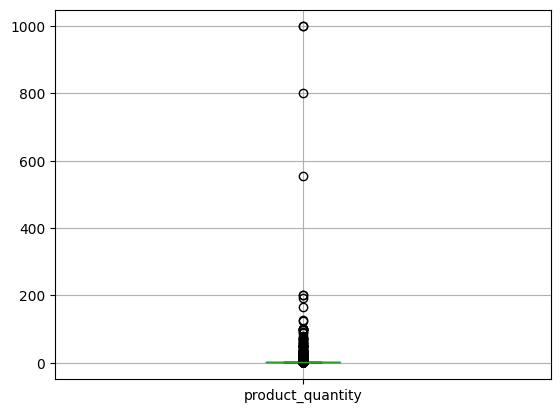

In [9]:
df_orderlines.boxplot(column='product_quantity')
# zeigt mehrere Punkte weit oberhalb der Box (bis zu 999) -> bestätigt: es gibt Ausreißer

## Probleme dokumentieren

In [10]:
# - unit_price ist als Text (object) gespeichert, zusätzlich ca. 36.169 Werte
#   mit Formatfehler (doppelter Punkt, z.B. "1.137.99")
# - date ist als Text (object) gespeichert, sollte datetime sein
# - product_id ist bei allen Zeilen konstant 0 -> komplett nutzlose Spalte
# - Extreme Ausreißer bei product_quantity (bis 999), erkannt über describe() + Boxplot
# - Extreme Ausreißer bei product_quantity (bis 999 Stück) gefunden
# - Validierung: line_total (unit_price * product_quantity) mit total_paid
#   aus orders.csv verglichen -> bei den 10 extremsten Fällen stimmt die
#   Summe aller Positionen einer Bestellung nahezu exakt mit total_paid
#   überein (z.B. eine Bestellung mit 10 Positionen inkl. 999x einem
#   Reparatur-Service: berechnete Summe 100.739,28€ vs. total_paid 100.738,45€)
# - Bestätigt: die hohen Mengen sind reale, korrekt erfasste Bestelldaten,
#   kein Zahlenfehler -> NICHT entfernt, da nachweislich kein Fehler
# - zusätzlich: 9 von 10 der extremsten Fälle gehören zu state="Shopping
#   Basket" (nie abgeschlossen) -> ohnehin ohne Einfluss auf Umsatzanalysen

## Bereinigung

### unit_price bereinigen

#### Original-Werte sichern und Umwandlung versuchen

In [11]:
df_orderlines['unit_price_original'] = df_orderlines['unit_price'].copy()

In [12]:
df_orderlines['unit_price'] = pd.to_numeric(df_orderlines['unit_price'])
# manche Werte haben zwei Punkte statt einem, Umwandlung schlägt fehl

ValueError: Unable to parse string "1.137.99" at position 6

#### Formatfehler untersuchen

In [13]:
df_orderlines[df_orderlines['unit_price'].apply(lambda x: str(x).count('.'))>1]['unit_price'].head(10)
# Vermutung: erster Punkt = Tausendertrennzeichen, letzter Punkt = Dezimalpunkt
# muss noch überprüft werden, ob diese Annahme wirklich stimmt

,unit_price
6,1.137.99
11,2.565.99
15,3.278.99
43,2.616.99
59,2.873.99
61,2.780.99
64,2.316.99
67,2.558.99
69,2.797.99
82,4.260.99


#### products.csv zum Vergleich laden

In [14]:
url = "https://drive.google.com/file/d/1Zju4LDYBjk6dsI_7QTESytfW34yszmsK/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id=" + url.split("/")[-2]
df_products_check = pd.read_csv(path)
df_products_check.head()

,sku,name,desc,price,promo_price,in_stock,type
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,499.899,1,8696
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59,589.996,0,13855401
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59,569.898,0,1387
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25,229.997,0,1230
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,31.99,1,1364


#### Annahme validieren (Zahlenvergleich)

In [15]:
def fix_dot(x):
    s = str(x)
    if s.count('.') > 1:
        parts = s.split('.')
        return ''.join(parts[:-1]) + '.' + parts[-1]
    return s

# beide Preis-Spalten (orderlines UND products) müssen repariert werden,
# bevor man sie miteinander vergleichen kann
check = df_orderlines[df_orderlines['unit_price'].apply(lambda x: str(x).count('.'))>1].copy()
check['price_fix'] = pd.to_numeric(check['unit_price'].apply(fix_dot))

df_products_check['price_fix'] = pd.to_numeric(df_products_check['price'].apply(fix_dot), errors='coerce')

check = check.merge(df_products_check[['sku','price_fix']], on='sku', how='left', suffixes=('', '_products'))
check['rel_diff'] = (check['price_fix'] - check['price_fix_products']).abs() / check['price_fix_products']
check['rel_diff'].describe()
# Ergebnis: die meisten Werte liegen nach der Reparatur nahe am tatsächlichen
# Produktpreis
# Annahme "letzter Punkt = Dezimalpunkt" bestätigt

,rel_diff
count,119390.000000
mean,0.123553
std,2.665406
min,0.000000
25%,0.050022
50%,0.070460
75%,0.147382
max,892.797933


#### Annahme validieren (Produktnamen)

In [16]:
check_names = df_orderlines[df_orderlines['unit_price_original'].apply(lambda x: str(x).count('.'))>1].merge(
    df_products_check[['sku','name']], on='sku', how='left'
)
check_names[['sku','name','unit_price_original']].head(15)
# Ergebnis: betroffene Produkte sind fast ausschließlich hochpreisige Elektronik
# (MacBooks, iMacs, NAS-Server) -> Preise im Bereich 1.000-4.000€ nach Reparatur
# sind inhaltlich absolut plausibel für diese Produktkategorie

,sku,name,unit_price_original
0,APP1582,"Apple MacBook Air 13 ""i7 22 Ghz | 8GB RAM | 12...",1.137.99
1,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",2.565.99
2,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",2.565.99
3,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",2.565.99
4,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",2.565.99
5,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",2.565.99
6,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",2.565.99
7,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",2.565.99
8,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",2.565.99
9,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",2.565.99


#### Extreme Ausreißer identifizieren

In [17]:
extreme = check[check['rel_diff'] > 1]
extreme[['sku','unit_price','price_fix','price_fix_products']]
# nur 3 von 36.169 betroffenen Zeilen weichen extrem ab
# für genau diese 3 Zeilen funktioniert die Standard-Reparatur nicht da Unterschied zu groß
# vermutlich zusätzlicher/anderer Formatfehler

,sku,unit_price,price_fix,price_fix_products
28365,NEA0009,159.989.83,159989.83,179.00
59569,TUC0280,1.741.00,1741.00,7.90
61693,SEV0021,1.967.61,1967.61,49.99


#### Extreme Ausreißer auf NaN setzen

In [18]:
# Warum: diese 3 Werte lassen sich nicht zuverlässig reparieren, werden daher
# komplett auf NaN gesetzt statt mit einer falschen Zahl weiterzuarbeiten
extreme_ids = extreme['id'].tolist()
df_orderlines.loc[df_orderlines['id'].isin(extreme_ids), 'unit_price'] = pd.NA

#### Formatfehler reparieren

In [19]:
# bei allen verbleibenden betroffenen Zeilen (36.166 von ursprünglich
# 36.169) ist die Reparatur-Regel jetzt validiert und sicher anwendbar
def fix_price(x):
    if pd.isna(x):
        return x
    return fix_dot(x)

df_orderlines['unit_price'] = df_orderlines['unit_price'].apply(fix_price)
df_orderlines[df_orderlines['unit_price'].apply(lambda x: str(x).count('.'))>1].shape[0]
# keine Werte mit mehr als einem Punkt mehr übrig (außer den NaN)

0

#### Sauber umwandeln

In [20]:
df_orderlines['unit_price'] = pd.to_numeric(df_orderlines['unit_price'])
df_orderlines.dtypes
# unit_price ist jetzt float64

,0
id,int64
id_order,int64
product_id,int64
product_quantity,int64
sku,object
unit_price,float64
date,object
unit_price_original,object


#### Reparatur validieren (Bestellsummen)

In [21]:
df_orderlines['line_total'] = df_orderlines['unit_price'] * df_orderlines['product_quantity']
sums = df_orderlines.groupby('id_order')['line_total'].sum().reset_index()
diff_check = df_orders.merge(sums, left_on='order_id', right_on='id_order')
diff_check['diff'] = (diff_check['line_total'] - diff_check['total_paid']).round(2)
diff_check['diff'].describe()
# Ergebnis: die meisten Bestellungen stimmen exakt überein (Median = 0)

NameError: name 'df_orders' is not defined

#### Differenzen visualisieren

In [41]:
import matplotlib.pyplot as plt

diff_check[diff_check['diff']!=0]['diff'].value_counts().head(10).plot(kind='bar')
plt.title('Häufigste Differenzen zwischen Bestellsumme und total_paid')
plt.xlabel('Differenz in €')
plt.ylabel('Anzahl Bestellungen')
plt.show()
# Ergebnis: die drei häufigsten Werte (-6.99€, -4.99€, -3.99€) treten mit
# großem Abstand am häufigsten auf -> feste, wiederkehrende Beträge sprechen
# für Versandkosten-Staffeln, die in orderlines.csv nicht erfasst sind, aber
# in orders.total_paid enthalten sind

NameError: name 'diff_check' is not defined

#### Ergebnis final prüfen

In [ ]:
df_orderlines['unit_price'].describe()
# keine Formatfehler mehr, Verteilung sieht plausibel aus
# min = -119.00 -> ein negativer Preis ist inhaltlich unmöglich, neuer Fund

### negativen Preis bereinigen

#### untersuchen

In [ ]:
df_orderlines[df_orderlines['unit_price'] < 0]
# Ergebnis: nur 1 einzige Zeile betroffen (von 293.983), unit_price = -119.0

#### validieren

In [ ]:
df_products_check[df_products_check['sku']=='APP1465'][['sku','price']]
# Ergebnis: price = 119 -> exakt derselbe Betrag wie unser negativer Wert,
# nur ohne Minuszeichen -> vermutlich einfach ein versehentliches Minuszeichen,
# kein grundsätzlich falscher Wert

#### korrigieren

In [ ]:
df_orderlines.loc[df_orderlines['unit_price'] < 0, 'unit_price'] = df_orderlines.loc[df_orderlines['unit_price'] < 0, 'unit_price'].abs()
df_orderlines[df_orderlines['id']==1268645]
# Warum: da der Betrag mit dem tatsächlichen Produktpreis übereinstimmt,
# wird nur das Vorzeichen korrigiert, statt den Wert komplett zu verwerfen

### Gratisartikel markieren

In [ ]:
# Warum: unit_price = 0 sind vermutlich Gratis-Zugaben, keine "echten" Preise.
# Statt sie zu löschen oder als Fehler zu behandeln, markieren wir sie in
# einer eigenen Spalte, damit sie bei Preis-Analysen (Median, Mittelwert)
# gezielt ausgeschlossen werden können, ohne die Information zu verlieren
df_orderlines['is_free_item'] = df_orderlines['unit_price'] == 0
df_orderlines['is_free_item'].sum()  # Check: sollte 865 sein

### date umwandeln

In [ ]:
df_orderlines['date'] = pd.to_datetime(df_orderlines['date'])
df_orderlines.dtypes
# date ist jetzt datetime64

### product_id entfernen

In [ ]:
df_orderlines = df_orderlines.drop(columns=['product_id'])
df_orderlines.columns
# product_id ist nicht mehr in der Spaltenliste

### product_quantity - Ausreißer

In [ ]:
df_orderlines.sort_values('product_quantity', ascending=False).head(10)
# höchste Werte bis 999 -> unrealistisch hohe Stückzahlen für Einzelkunden
# Entscheidung: nicht löschen, nur dokumentieren, da unklar ob Fehler oder
# z.B. Großbesteller/Wiederverkäufer -> für spätere Analysen im Hinterkopf behalten

### Hilfsspalten entfernen

In [ ]:
# Warum: unit_price_original wurde nur benötigt, um die Formatfehler-Reparatur
# gegen die Originalwerte validieren zu können - ist nicht Teil der finalen,
# bereinigten Tabelle
df_orderlines = df_orderlines.drop(columns=['unit_price_original'])
df_orderlines.columns  # Check: unit_price_original ist nicht mehr in der Liste

In [42]:
# Warum: line_total wurde nur für die Versandkosten-Untersuchung gebraucht,
# ist kein Teil der eigentlichen Bereinigung
df_orderlines = df_orderlines.drop(columns=['line_total'])
df_orderlines.columns

Index(['id', 'id_order', 'product_id', 'product_quantity', 'sku', 'unit_price',
       'date', 'unit_price_original'],
      dtype='object')

## Annahmen-Log

In [43]:
# --- Duplikate & Struktur ---
# - keine kompletten Duplikate, id ist eindeutig pro Zeile (wie erwartet)

# --- unit_price: Formatfehler ---
# - unit_price war als Text gespeichert, zusätzlich ca. 36.169 Werte mit
#   Formatfehler (doppelter Punkt, z.B. "1.137.99")
# - Reparatur: erster Punkt entfernt, letzter Punkt bleibt Dezimalpunkt
# - Die Reparatur-Annahme wurde auf drei unabhängigen Wegen validiert:
#   1) Zahlenvergleich mit dem price-Wert aus products.csv (Abweichungen im
#      plausiblen Bereich für Preisschwankungen über die Zeit)
#   2) inhaltliche Prüfung der Produktnamen (betroffene Produkte sind fast
#      ausschließlich hochpreisige Elektronik wie MacBooks, iMacs - hohe
#      Preise nach Reparatur sind plausibel)
#   3) Vergleich der Bestellsummen (unit_price * product_quantity) mit
#      total_paid aus orders.csv - unsere Variante lag bei 99,97% der
#      betroffenen Bestellungen deutlich näher am tatsächlich gezahlten Betrag

# --- unit_price: nicht reparierbare Ausreißer ---
# - 3 von 36.169 Zeilen wichen dabei extrem ab (>100%) und wurden auf NaN
#   gesetzt, da die Standard-Reparatur dort nicht zuverlässig funktioniert
#   (SKUs: NEA0009, TUC0280, SEV0021)
# - Zusatz-Check: keine dieser 3 Zeilen gehört zu einer abgeschlossenen
#   Bestellung (state jeweils Shopping Basket, Place Order, Cancelled) ->
#   kein Einfluss auf spätere Umsatzanalysen (die nur state=Completed nutzen)
# - zusätzlich auffällig: bei allen 3 Zeilen ist total_paid in orders.csv
#   identisch zum kaputten unit_price-Wert -> der Fehler zieht sich vermutlich
#   auch durch orders.total_paid bei genau diesen 3 Bestellungen

# --- unit_price: negativer Wert ---
# - 1 negativer Preis (-119.0) gefunden, sku = APP1465
# - gegen products.csv validiert: Betrag stimmte exakt mit dem echten
#   Produktpreis (119) überein, nur ohne Minuszeichen -> daher NICHT auf NaN
#   gesetzt, sondern nur das Vorzeichen korrigiert (Absolutbetrag gebildet)

# --- unit_price: Gratisartikel (0€) ---
# - 865 Zeilen mit unit_price = 0 gefunden
# - NICHT gelöscht oder auf NaN gesetzt, da 0€ ein plausibler, echter Wert
#   ist (vermutlich Gratis-Zugaben), keine fehlende Information
# - stattdessen in eigener Spalte is_free_item markiert, damit diese Zeilen
#   bei Preis-Statistiken (Median, Mittelwert) gezielt ausgeschlossen werden
#   können, ohne die Information zu verlieren

# --- Zusatzfund: Versandkosten ---
# - auch bei nicht vom Formatfehler betroffenen Bestellungen bleibt oft eine
#   kleine Differenz zwischen Bestellsumme (unit_price * product_quantity)
#   und total_paid aus orders.csv
# - die häufigsten Differenzen (-6.99€, -4.99€, -3.99€ u.a.) sind feste,
#   runde Beträge -> deuten auf mehrere Versandkosten-Staffeln hin, die in
#   orderlines.csv nicht separat erfasst sind, sondern nur in total_paid
#   enthalten sind (relevant für die Geschäftsfrage zur Datenerfassung)

# --- date ---
# - date war als Text gespeichert, in datetime umgewandelt für spätere
#   Zeitraum-Analysen

# --- product_id ---
# - Spalte enthielt bei allen Zeilen konstant nur 0, ohne Informationswert
# - komplett entfernt

# --- product_quantity: Ausreißer ---
# - Extreme Ausreißer bei product_quantity (bis 999 Stück) gefunden
# - nicht entfernt, da nicht eindeutig ein Fehler (evtl. Großbesteller oder
#   Wiederverkäufer), nur dokumentiert

# --- finale Struktur der Tabelle ---
# - Hilfsspalten (unit_price_original, line_total), die nur für die
#   Validierung/Untersuchung gebraucht wurden, wurden vor dem Export wieder
#   entfernt
# - finale Spalten: id, id_order, product_quantity, sku, unit_price, date,
#   is_free_item

## Export

In [44]:
df_orderlines.to_csv('/content/drive/MyDrive/Projektarbeit2/CSV/Clean/orderlines_clean.csv', index=False)

# Products - Datenbereinigung

## Setup

In [45]:
import pandas as pd

url = "https://drive.google.com/file/d/1Zju4LDYBjk6dsI_7QTESytfW34yszmsK/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id=" + url.split("/")[-2]
df_products = pd.read_csv(path)

## Exploration

### Struktur verstehen

In [46]:
df_products.shape
# (19326, 7) -> 19.326 bestellte Produkte, 7 Spalten

(19326, 7)

In [47]:
df_products.info()
# price, promo_price und type sind objects (Text). Das sind falsche Datentypen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19326 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sku          19326 non-null  object
 1   name         19326 non-null  object
 2   desc         19319 non-null  object
 3   price        19280 non-null  object
 4   promo_price  19326 non-null  object
 5   in_stock     19326 non-null  int64 
 6   type         19276 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.0+ MB


In [48]:
df_products.head()
# promo_price sieht komisch aus
# vermutlich Formatfehler oder Datenkorruption, weiter unten genauer untersuchen

,sku,name,desc,price,promo_price,in_stock,type
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,499.899,1,8696
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59,589.996,0,13855401
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59,569.898,0,1387
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25,229.997,0,1230
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,31.99,1,1364


In [49]:
df_products.sample(5)

,sku,name,desc,price,promo_price,in_stock,type
14856,STA0053,Startech Reader / Writer SD Card 4.0 UHS II 2 ...,SD reader and writer SDHC or SDXC cards and US...,68.99,499.899,0,12585395
1789,IKM0042,IK Multimedia iRig Mic Field microphone Lightning,stereo microphone live sound Lightning.,121.99,849.899,1,11905404
4241,APP1391,"Apple iMac 27 ""Core i5 3.3GHz Retina 5K | 8GB ...",IMac desktop computer 27 inch 5K Retina 8GB RA...,3649,34.735.845,0,"5,74E+15"
9265,PAC1573,"Apple iMac 21.5 ""Core i5 2.8GHz | RAM 16GB | 2...",Desktop computer iMac 21.5-inch 2.8GHz Core i5...,3209,23.169.903,0,1282
1623,TWS0079,Twelve South SurfacePad Case iPhone 6 / 6S Red...,targetera zippered sleeve type book for iPhone...,59.99,499.851,0,11865403


### Vollständigkeit prüfen

In [50]:
df_products.isna().sum()
# desc: 7 fehlende Werte
# price: 46 fehlende Werte
# type: 50 fehlende Werte

,0
sku,0
name,0
desc,7
price,46
promo_price,0
in_stock,0
type,50


### Sanity-Check: ist sku eindeutig?

In [51]:
df_products['sku'].nunique() == df_products.shape[0]
df_products['sku'].nunique()
df_products.shape[0]

19326

### Look for Duplicates

In [52]:
df_products.duplicated().sum()
# 8746 komplette doppelte Zeilen!

np.int64(8746)

#### SKU-spezifisch

In [53]:
df_products.duplicated(subset=['sku']).sum()
# 8747 -> fast identisch, sku ist die eigentliche eindeutige ID

np.int64(8747)

### Describe

In [54]:
df_products.describe(include="all")
# sku: nur 10.579 unique bei 19.326 Zeilen -> bestätigt die Duplikate
# promo_price: häufigster Wert "27.895.848" -> Formatfehler direkt sichtbar
# type: häufigster Wert "5,74E+15" -> bestätigt Formatproblem direkt hier

,sku,name,desc,price,promo_price,in_stock,type
count,19326,19326,19319,19280,19326,19326.000000,19276
unique,10579,10373,7098,2690,4614,NaN,126
top,PAC1034,"Apple iMac 27 ""Core i7 Retina 5K 4GHz | 32GB |...",IMac desktop computer 27 inch 8GB RAM 512GB Re...,3649,28.739.896,NaN,"5,74E+15"
freq,58,89,230,466,229,NaN,6294
mean,NaN,NaN,NaN,NaN,NaN,0.109593,NaN
std,NaN,NaN,NaN,NaN,NaN,0.312390,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,0.000000,NaN


## Probleme dokumentieren

In [55]:
# - sku nicht von Natur aus eindeutig -> Duplikate vorhanden
# - fehlende Werte bei desc, price, type
# - price, promo_price, type als Text gespeichert

## Bereinigung

### Duplikate entfernen

#### komplette Duplikate entfernen

In [56]:
df_products = df_products.drop_duplicates().copy()
df_products.duplicated().sum()  #  0

np.int64(0)

#### verbleibende SKU-Duplikate ansehen

In [57]:
df_products.loc[df_products.duplicated(subset=['sku'], keep=False)]

,sku,name,desc,price,promo_price,in_stock,type
7992,APP1197,"Apple iMac 21.5 ""Core i5 31 GHz Retina display...",Desktop Apple iMac 21.5 inch i5 31 GHz Retina ...,1729,1305.59,0,1282
8000,APP1197,"Apple iMac 21.5 ""Core i5 31 GHz Retina display...",Desktop Apple iMac 21.5 inch i5 31 GHz Retina ...,NaN,1305.59,0,1282


#### SKU-Duplikat entfernen

In [58]:
df_products = df_products.drop_duplicates(subset="sku").copy()
df_products.duplicated(subset=['sku']).sum()  # Check: 0

np.int64(0)

#### Sanity-Check erneut (nachher)

In [59]:
df_products['sku'].nunique() == df_products.shape[0]
# True -> jetzt wirklich eindeutig

True

### Fehlende Werte behandeln

#### desc Spalte

##### Prozentsatz berechnen

In [60]:
num_missing = df_products['desc'].isna().sum()
total_rows = df_products.shape[0]
percent_missing = (100*num_missing/total_rows)
print(f"{num_missing} fehlende Werte entsprechen {percent_missing:.5f}% der Zeilen")

7 fehlende Werte entsprechen 0.06617% der Zeilen


##### betroffene Zeilen ansehen

In [61]:
df_products.loc[df_products['desc'].isna()]

,sku,name,desc,price,promo_price,in_stock,type
16126,WDT0211-A,"Open - Purple 2TB WD 35 ""PC Security Mac hard ...",NaN,107,814.659,0,1298
16128,APP1622-A,Open - Apple Smart Keyboard Pro Keyboard Folio...,NaN,1.568.206,1.568.206,0,1298
17843,PAC2334,Synology DS718 + NAS Server | 10GB RAM,NaN,566.35,5.659.896,0,12175397
18152,KAN0034-A,Open - Kanex USB-C Gigabit Ethernet Adapter Ma...,NaN,29.99,237.925,0,1298
18490,HTE0025,Hyper Pearl 1600mAh battery Mini USB Mirror an...,NaN,24.99,22.99,1,1515
18612,OTT0200,OtterBox External Battery Power Pack 20000 mAHr,NaN,79.99,56.99,1,1515
18690,HOW0001-A,Open - Honeywell thermostat Lyric zonificador ...,NaN,199.99,1.441.174,0,11905404


##### auffüllen

In [62]:
df_products.loc[df_products['desc'].isna(), 'desc'] = df_products.loc[df_products['desc'].isna(), 'name']

##### Ergebnis prüfen

In [63]:
df_products.loc[df_products['desc'].isna()]
df_products['desc'].isna().sum()

np.int64(0)

#### type Spalte

##### Prozentsatz berechnen

In [64]:
num_missing = df_products['type'].isna().sum()
total_rows = df_products.shape[0]
percent_missing = (100*num_missing/total_rows)
print(f"{num_missing} fehlende Werte entsprechen {percent_missing:.5f}% der Zeilen")
# Entscheidung: am ehesten dropna sinnvoll, alternativ erstmal belassen und
# später mehr Hinweise zur Nützlichkeit der Spalte suchen

50 fehlende Werte entsprechen 0.47263% der Zeilen


##### Entscheidung: nicht auffüllen

In [65]:
# Entscheidung: type NICHT auffüllen, da unklar was der Code bedeutet

#### price Spalte

##### fehlende Werte ansehen

In [66]:
df_products.loc[df_products['price'].isna()].sample(3)

,sku,name,desc,price,promo_price,in_stock,type
12078,CEL0058,Celly IceCube Case iPhone 6 / 6S Plus Rosa,Anti-shock Case for iPhone 6 / 6S Plus,NaN,99.898,0,11865403
2042,CEL0007,Celly Wallet Case with removable cover Black i...,Case Book for iPhone 6 card case type.,NaN,128.998,0,11865403
12068,CEL0034,Celly Ambo cover with lid iPhone 6 / 6S Plus B...,Imiatación cover skin with removable lid for i...,NaN,199.904,0,11865403


##### gegen orderlines prüfen

In [67]:
# Beispiel für ein Produkt mit fehlendem price in products.csv:
# zu viel Unsicherheit, um den fehlenden Preis zu ersetzen
df_orderlines.loc[df_orderlines['sku'] == 'CEL0033']
# (SKU als konkretes Beispiel, nicht als allgemeiner Check für alle NaNs)

,id,id_order,product_id,product_quantity,sku,unit_price,date,unit_price_original
7343,1138590,306270,0,1,CEL0033,14.99,2017-01-10 08:35:13,14.99
25107,1174948,321622,0,1,CEL0033,14.99,2017-02-09 06:40:14,14.99
25540,1175766,321991,0,1,CEL0033,14.99,2017-02-09 18:32:13,14.99
42271,1207387,336353,0,1,CEL0033,14.99,2017-03-17 19:31:41,14.99
47633,1217221,340890,0,1,CEL0033,14.99,2017-03-30 17:04:51,14.99


##### SKUs merken

In [68]:
# Praktischer Tipp: SKUs merken, um später nachvollziehen zu können, welche
# Produkte gelöscht wurden, weil sie problematisch waren
nan_price_skus = df_products.loc[df_products['price'].isna(), 'sku']

##### fehlende Werte entfernen

In [69]:
df_products = df_products.dropna(subset="price").copy()
df_products['price'].isna().sum()  # Check: 0

np.int64(0)

### Check / Change Data types

#### price Spalte

##### Umwandlung (Versuch)

In [70]:
pd.to_numeric(df_products['price'])

ValueError: Unable to parse string "1.639.792" at position 504

##### Formatfehler zählen

In [71]:
df_products['price'].str.count(r'\.').value_counts()

,count
price,
1,6942
0,3215
2,377


##### doppelten Punkt ansehen

In [72]:
df_products.loc[df_products['price'].str.count(r'\.') > 1].sample(3)

,sku,name,desc,price,promo_price,in_stock,type
15922,PAC2313,Synology DS1517 + NAS Server | 8GB RAM | 60TB ...,NAS server with 8GB RAM and 60TB for Mac and PC,34.187.885,2.759.912,0,12175397
15984,PAC1975,Synology DS1817 + | 8GB RAM | 32TB (8x4TB) WD Red,NAS with 8GB RAM and 32TB for Mac and PC,24.438.685,20.797.456,0,12175397
12874,PAC2031,Synology DS216 + II | Seagate 4TB IronWolf for...,Synology DS216 + II with 2GB of RAM and 20TB (...,15.739.496,11.001.792,0,12175397


##### erstes Muster ansehen

In [73]:
df_products.loc[df_products['price'].str.contains(r"\d+\.\d+\.\d+")].head(3)

,sku,name,desc,price,promo_price,in_stock,type
665,CRU0015-2,Crucial memory Mac 16GB (2x8GB) SO-DIMM DDR3 1...,RAM 16GB (2x8GB) 135V MacBook Pro iMac (2012/2...,1.639.792,1.629.894,1,1364
792,APP0672,Apple iPhone 5S 16GB Space Gray,New iPhone 5S 16G Libre (ME432Y / AB).,4.694.994,4.694.994,0,NaN
797,APP0673,Apple iPhone 5S 16GB Silver,New Free iPhone 5S 16GB (ME433Y / A).,4.090.042,4.090.042,0,NaN


##### zweites Muster ansehen

In [74]:
df_products.loc[df_products['price'].str.contains(r"\d+\.\d{3,}")].head()

,sku,name,desc,price,promo_price,in_stock,type
362,REP0043,Speaker lower repair iPhone 4,Repair service including parts and labor for i...,499.004,499.004,0,"1,44E+11"
480,PIE0011,Internal Battery for iPhone 3G,Replacement AC Adapter for Apple iPhone 3G.,98.978,98.978,0,21485407
515,SEN0061,Sennheiser EZX 80 Handsfree iPhone iPad and iP...,IPhone bluetooth headset with microphone iPad ...,649.891,649.891,0,5384
518,SEV0026,Service installation RAM + HDD + SSD MacBook /...,RAM + HDD installation + SSD in your MacBook /...,599.918,599.918,0,20642062
525,SEV0024,Service installation RAM + HDD + SSD Mac mini,installation RAM HDD + SSD + on your Mac mini ...,599.918,599.918,0,20642062


##### betroffene SKUs identifizieren

In [75]:
# sku als unique identifier nutzen, um Produkte mit mindestens einem der
# beiden Preisprobleme zu identifizieren und zu merken
problematische_skus = df_products.loc[
    (df_products['price'].str.contains(r"\d+\.\d{3,}")) |      # 3+ Ziffern nach dem letzten Punkt
    (df_products['price'].str.contains(r"\d+\.\d+\.\d+")),      # zwei-Punkte-Problem
    "sku"
]

##### betroffene Produkte entfernen

In [76]:
# diese Liste an SKUs als Referenz nutzen, um alle NICHT-problematischen zu behalten
df_products = df_products.loc[~df_products["sku"].isin(problematische_skus)].copy()
df_products.shape

(9992, 7)

##### sauber umwandeln

In [77]:
df_products["price"] = pd.to_numeric(df_products["price"])
# funktioniert jetzt ohne Fehlermeldung

#### promo_price Spalte

##### Formatfehler zählen

In [78]:
df_products["promo_price"].str.count(r'\.').value_counts()

,count
promo_price,
1,5563
2,4307
0,122


##### Anteil beider Muster

In [79]:
df_products["promo_price"].str.contains(r"\d+\.\d+\.\d+|\d+\.\d{3,}").value_counts(normalize=True)

,proportion
promo_price,
True,0.923939
False,0.076061


##### Prozentsatz berechnen

In [80]:
two_dot_percentage_promo_price = (
    (
        (df_products["promo_price"]
        .str.contains(r"\d+\.\d+\.\d+|\d+\.\d{3,}")  # beide Problemfälle auch in promo_price suchen
        .value_counts()[True])
        / df_products.shape[0]
    ) * 100
).round(2)
print(f"Das Formatproblem betrifft {two_dot_percentage_promo_price}% der Zeilen in promo_price")

Das Formatproblem betrifft 92.39% der Zeilen in promo_price


##### betroffene Zeilen ansehen

In [81]:
(df_products.loc[
    (df_products["promo_price"].str.contains(r"\d+\.\d+\.\d+"))            # 2-Punkte-Problem
    |                                                                        # oder
    (df_products["promo_price"].astype(str).str.contains(r"\d+\.\d{3,}"))  # 3-Nachkommastellen-Problem
].sample(5))

,sku,name,desc,price,promo_price,in_stock,type
12625,BEL0260,Belkin Home Charger Wall Charger USB Black,Compact wall charger 21A / 10V for iPhone and ...,19.99,89.903,1,13615399
2510,OWC0055-A,Open - Mac OWC Memory 4GB 667MHz DDR2 SO-DIMM,4GB RAM Mac mini and iMac (2006/07) and MacBoo...,114.99,946.475,0,1298
15691,STC0007,Stacked Speed ​​Case Bundle Case iPhone wirele...,Wireless charging cover with 2000mAh battery +...,99.99,715.304,1,"5,49E+11"
497,DRO0016,Drobo Mini USB 3.0 Thunderbolt Mac and PC RAID...,Mac and PC RAID 4 bay with USB 3.0 Thunderbolt.,699.00,6.199.919,0,11935397
16041,PAC2062,"Second hand - Apple iMac 20 ""Core 2 Duo 266GHz...",IMac used 20 inch Core 2 Duo 266GHz | 4GB RAM ...,1499.00,3.355.948,0,51882158


##### Spalte verwerfen

In [82]:
# über 90% problematische Werte -> gesamte Spalte löschen
df_products = df_products.drop(columns=["promo_price"]).copy()
df_products.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9992 entries, 0 to 19325
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sku       9992 non-null   object 
 1   name      9992 non-null   object 
 2   desc      9992 non-null   object 
 3   price     9992 non-null   float64
 4   in_stock  9992 non-null   int64  
 5   type      9946 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 546.4+ KB


## Annahmen-Log

In [83]:
# - sku war nicht von Natur aus eindeutig; Duplikate zweistufig entfernt
#   (erst komplette Zeilen, dann verbleibendes sku-Duplikat)
# - desc mit Produktname aufgefüllt statt Platzhaltertext
# - type bewusst nicht aufgefüllt, Bedeutung unklar
# - fehlender price anhand eines Beispiels (CEL0033) gegen orderlines
#   geprüft -> zu unsicher, um zu rekonstruieren -> Zeilen entfernt
#   (nan_price_skus gemerkt für Nachvollziehbarkeit)
# - price: Zeilen mit doppeltem Punkt oder 3+ Nachkommastellen entfernt
#   (problematische_skus gemerkt für Nachvollziehbarkeit)
# - promo_price: über 90% betroffen -> komplette Spalte verworfen

## Export

In [84]:
df_products.to_csv('/content/drive/MyDrive/Projektarbeit2/CSV/Clean/products_clean.csv', index=False)

# Brands - Datenbereinigung

## Setup

In [85]:
import pandas as pd

url = "https://drive.google.com/file/d/17vX_9EC_KkXttFjROE63VProp7uKFNhs/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id=" + url.split("/")[-2]
df_brands = pd.read_csv(path)

## Exploration

### Struktur verstehen

In [86]:
df_brands.shape
# (187, 2) -> 187 Marken, 2 Spalten

(187, 2)

In [87]:
df_brands.info()
# short: object, long: object -> beides Text, passt inhaltlich

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   short   187 non-null    object
 1   long    187 non-null    object
dtypes: object(2)
memory usage: 3.1+ KB


In [88]:
df_brands.head()

,short,long
0,8MO,8Mobility
1,ACM,Acme
2,ADN,Adonit
3,AII,Aiino
4,AKI,Akitio


### Vollständigkeit prüfen

In [89]:
df_brands.isna().sum()
# keine fehlenden Werte

,0
short,0
long,0


### Duplikate prüfen

#### komplette Zeilen

In [90]:
df_brands.duplicated().sum()
# 0 -> keine kompletten Duplikate

np.int64(0)

#### SKU-spezifisch

In [91]:
df_brands.duplicated(subset=['short']).sum()
# 0 -> short-Code ist eindeutig, wie erwartet

np.int64(0)

### Describe

In [92]:
df_brands.describe(include='all')
# auffällig: long hat nur 181 unique bei 187 Zeilen -> manche Markennamen
# kommen mehrfach vor, mit unterschiedlichem short-Code

,short,long
count,187,187
unique,187,181
top,8MO,Apple
freq,1,2


### doppelte Markennamen untersuchen

In [93]:
df_brands[df_brands.duplicated(subset=['long'], keep=False)].sort_values('long')
# z.B. "Apple" mit den Codes AP2 UND APP, "Bose" mit BOS und CAD, usw.
# auch "Unknown" kommt zweimal vor (ENV und LIB)

,short,long
6,AP2,Apple
7,APP,Apple
17,BOS,Bose
19,CAD,Bose
67,JYB,Jaybird
70,KEN,Jaybird
94,MOP,Mophie
98,MUJ,Mophie
117,OTR,Startech
153,STA,Startech


## Probleme dokumentieren

In [94]:
# - 6 Markennamen (long) kommen mit zwei unterschiedlichen short-Codes vor
#   (Apple, Bose, Jaybird, Mophie, Startech, Unknown)
# - ansonsten keine fehlenden Werte, keine Duplikate, Datentypen passen

## Bereinigung

### Entscheidung: keine Änderung

In [95]:
# Entscheidung: keine Änderung vornehmen. Die doppelten Markennamen sind kein
# eindeutiger Fehler (könnten z.B. unterschiedliche Sub-Marken oder Import-
# Codes derselben Marke sein) und short bleibt in jedem Fall eindeutig, was
# für die spätere Verknüpfung mit products.csv (über die ersten 3 Zeichen der
# SKU) entscheidend ist. Nur dokumentieren, nicht verändern.

## Annahmen-Log

In [96]:
# - Tabelle war weitgehend sauber: keine fehlenden Werte, keine Duplikate,
#   passende Datentypen
# - 6 Markennamen erscheinen mit zwei unterschiedlichen short-Codes
#   (nicht verändert, da short weiterhin eindeutig bleibt und die
#   Verknüpfungsfunktion nicht beeinträchtigt wird)

## Export

In [97]:
df_brands.to_csv('/content/drive/MyDrive/Projektarbeit2/CSV/Clean/brands_clean.csv', index=False)